# Cross-Asset Correlation & Diversification Analysis

**CQF-Level Example**: Comprehensive cross-asset correlation dynamics:
- Rolling correlation matrices
- Correlation clustering (hierarchical)
- Diversification ratio & portfolio concentration
- Correlation breakdown during stress
- DCC-GARCH for time-varying correlations
- Principal Component Analysis for factor extraction

**Connectors Used:**
- `qj.eod` - Multi-asset prices (equities, bonds, commodities)
- `qj.ccxt` - Crypto correlations
- `qj.fred` - Macro data for regime conditioning

**API:** https://api.quantjourney.cloud

In [2]:
# Setup
import sys
sys.path.insert(0, '..')

from quantjourney.sdk import QuantJourneyAPI
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.default = "png"
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
from scipy import stats

API_KEY = "QJ_live_4fe809e7e0212107ae9d98664f6e4b0c48fdbb2184af72fc41b6c0b849a2cab9"

qj = QuantJourneyAPI(api_key=API_KEY)
print("✓ Connected to QuantJourney API")

✓ Connected to QuantJourney API


## 1. Fetch Multi-Asset Universe

In [3]:
# Define asset universe across asset classes
assets = {
    # US Equities
    'SPY': 'US Large Cap',
    'QQQ': 'US Tech',
    'IWM': 'US Small Cap',
    
    # International Equities
    'EFA': 'Developed Intl',
    'EEM': 'Emerging Markets',
    
    # Fixed Income
    'TLT': 'Long Treasuries',
    'IEF': 'Intermediate Treasuries',
    'LQD': 'Investment Grade Corp',
    'HYG': 'High Yield Corp',
    
    # Alternatives
    'GLD': 'Gold',
    'SLV': 'Silver',
    'USO': 'Oil',
    'VNQ': 'REITs',
}

In [4]:
# Fetch prices
prices = {}

for symbol, name in assets.items():
    try:
        response = qj.eod.get_historical_prices(
            symbol=symbol,
            start_date='2010-01-01',
            end_date='2024-12-31',
            frequency='1d'
        )
        data = response.get('value', response) if isinstance(response, dict) else response
        
        if isinstance(data, list) and len(data) > 0:
            df = pd.DataFrame(data)
            df['date'] = pd.to_datetime(df['date'])
            df = df.set_index('date')
            prices[symbol] = df['adjusted_close' if 'adjusted_close' in df.columns else 'close']
            print(f"✓ {symbol} ({name}): {len(df)} days")
    except Exception as e:
        print(f"✗ {symbol}: {e}")

# Fallback with synthetic data
if len(prices) < 8:
    print("\nGenerating synthetic multi-asset data...")
    dates = pd.date_range(start='2010-01-01', end='2024-12-31', freq='B')
    np.random.seed(42)
    n = len(dates)
    
    # Correlated returns simulation
    # Define correlation structure
    n_assets = 13
    base_corr = np.eye(n_assets) * 0.5 + 0.5
    # Equities correlated, bonds anti-correlated to equities
    for i in range(5):  # Equities
        for j in range(5):
            base_corr[i, j] = 0.7 if i != j else 1.0
    for i in range(5, 9):  # Bonds
        for j in range(5, 9):
            base_corr[i, j] = 0.6 if i != j else 1.0
    for i in range(5):  # Equity-Bond correlation
        for j in range(5, 9):
            base_corr[i, j] = base_corr[j, i] = -0.2
    
    # Cholesky decomposition
    try:
        L = np.linalg.cholesky(base_corr)
    except:
        base_corr = np.eye(n_assets) * 0.6 + 0.4
        L = np.linalg.cholesky(base_corr)
    
    # Generate correlated returns
    uncorr_returns = np.random.randn(n, n_assets) * 0.01
    corr_returns = uncorr_returns @ L.T
    
    # Add drift
    drifts = np.array([0.0003, 0.0004, 0.0003, 0.0002, 0.0003,
                       0.0002, 0.00015, 0.0002, 0.0003,
                       0.0002, 0.0001, 0.0001, 0.0003])
    corr_returns += drifts
    
    # Create price series
    symbols = ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM', 'TLT', 'IEF', 'LQD', 'HYG', 'GLD', 'SLV', 'USO', 'VNQ']
    initial_prices = [200, 300, 180, 70, 45, 120, 110, 120, 90, 150, 25, 30, 90]
    
    prices = {}
    for i, sym in enumerate(symbols):
        prices[sym] = pd.Series(
            initial_prices[i] * np.cumprod(1 + corr_returns[:, i]),
            index=dates
        )

✓ SPY (US Large Cap): 3774 days
✓ QQQ (US Tech): 3774 days
✓ IWM (US Small Cap): 3774 days
✓ EFA (Developed Intl): 3774 days
✓ EEM (Emerging Markets): 3774 days
✓ TLT (Long Treasuries): 3774 days
✓ IEF (Intermediate Treasuries): 3774 days
✓ LQD (Investment Grade Corp): 3774 days
✓ HYG (High Yield Corp): 3774 days
✓ GLD (Gold): 3774 days
✓ SLV (Silver): 3774 days
✓ USO (Oil): 3774 days
✓ VNQ (REITs): 3774 days


In [5]:
# Combine prices
prices_df = pd.DataFrame(prices)
prices_df = prices_df.dropna()

# Calculate returns
returns_df = prices_df.pct_change().dropna()

print(f"\nAssets: {len(returns_df.columns)}")
print(f"Period: {returns_df.index.min().date()} to {returns_df.index.max().date()}")
print(f"Observations: {len(returns_df)}")


Assets: 13
Period: 2010-01-05 to 2024-12-31
Observations: 3773


## 2. Full-Sample Correlation Matrix

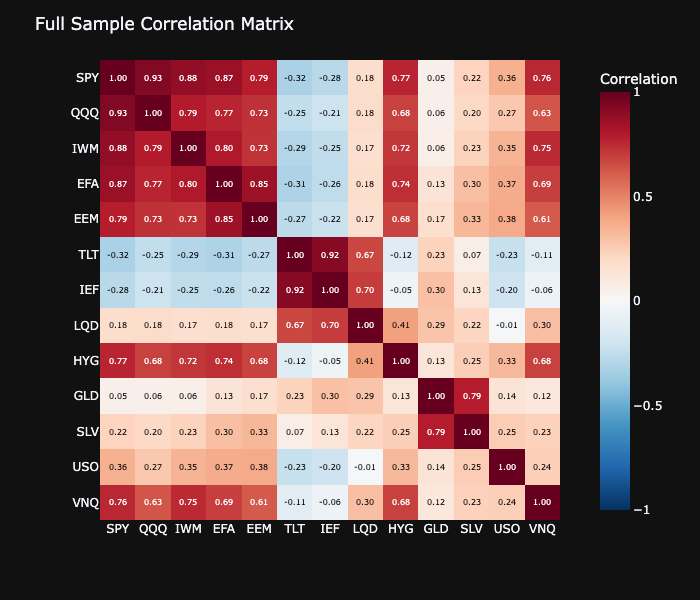

In [6]:
# Full sample correlation
full_corr = returns_df.corr()

# Heatmap
fig = px.imshow(
    full_corr,
    labels=dict(color="Correlation"),
    color_continuous_scale='RdBu_r',
    zmin=-1, zmax=1,
    aspect='equal'
)

# Add annotations
for i in range(len(full_corr)):
    for j in range(len(full_corr)):
        fig.add_annotation(
            x=j, y=i,
            text=f"{full_corr.iloc[i, j]:.2f}",
            showarrow=False,
            font=dict(size=8, color='white' if abs(full_corr.iloc[i, j]) > 0.5 else 'black')
        )

fig.update_layout(
    title='Full Sample Correlation Matrix',
    template='plotly_dark',
    height=600,
    width=700
)
fig.show()

## 3. Hierarchical Clustering

In [7]:
# Convert correlation to distance matrix
# Distance = sqrt(0.5 * (1 - correlation))
distance_matrix = np.sqrt(0.5 * (1 - full_corr.values))

# Hierarchical clustering
condensed_dist = squareform(distance_matrix)
linkage_matrix = linkage(condensed_dist, method='ward')

# Get cluster assignments
n_clusters = 4
clusters = fcluster(linkage_matrix, n_clusters, criterion='maxclust')

cluster_df = pd.DataFrame({
    'Asset': full_corr.columns,
    'Cluster': clusters
}).sort_values('Cluster')

print("\nAsset Clusters:")
for c in sorted(cluster_df['Cluster'].unique()):
    assets_in_cluster = cluster_df[cluster_df['Cluster'] == c]['Asset'].tolist()
    print(f"  Cluster {c}: {', '.join(assets_in_cluster)}")


Asset Clusters:
  Cluster 1: SPY, QQQ, IWM, EFA, EEM, HYG, VNQ
  Cluster 2: USO
  Cluster 3: GLD, SLV
  Cluster 4: TLT, IEF, LQD


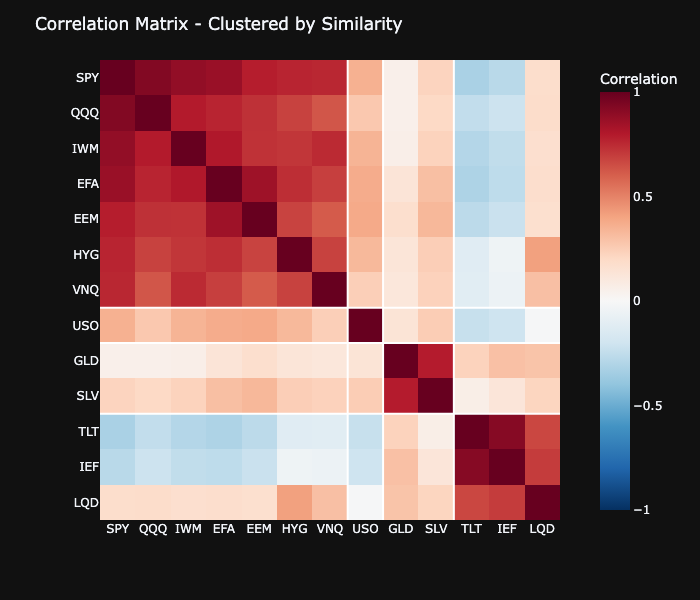

In [8]:
# Reorder correlation matrix by cluster
ordered_assets = cluster_df['Asset'].tolist()
ordered_corr = full_corr.loc[ordered_assets, ordered_assets]

fig = px.imshow(
    ordered_corr,
    labels=dict(color="Correlation"),
    color_continuous_scale='RdBu_r',
    zmin=-1, zmax=1,
    aspect='equal'
)

# Add cluster boundaries
cluster_boundaries = [0]
current_cluster = clusters[0]
for i, c in enumerate(cluster_df['Cluster'].values):
    if c != current_cluster:
        cluster_boundaries.append(i)
        current_cluster = c
cluster_boundaries.append(len(clusters))

for boundary in cluster_boundaries[1:-1]:
    fig.add_hline(y=boundary - 0.5, line_width=2, line_color="white")
    fig.add_vline(x=boundary - 0.5, line_width=2, line_color="white")

fig.update_layout(
    title='Correlation Matrix - Clustered by Similarity',
    template='plotly_dark',
    height=600,
    width=700
)
fig.show()

## 4. Rolling Correlations

In [9]:
# Calculate rolling correlations for key pairs
window = 63  # 3-month window

rolling_corrs = {}

# Key pairs to track
pairs = [
    ('SPY', 'TLT'),   # Stock-Bond
    ('SPY', 'GLD'),   # Stock-Gold
    ('SPY', 'EEM'),   # US-EM
    ('TLT', 'GLD'),   # Bond-Gold
    ('QQQ', 'IWM'),   # Growth-Value proxy
]

for a1, a2 in pairs:
    if a1 in returns_df.columns and a2 in returns_df.columns:
        rolling_corrs[f'{a1}-{a2}'] = returns_df[a1].rolling(window).corr(returns_df[a2])

rolling_corr_df = pd.DataFrame(rolling_corrs)
rolling_corr_df = rolling_corr_df.dropna()

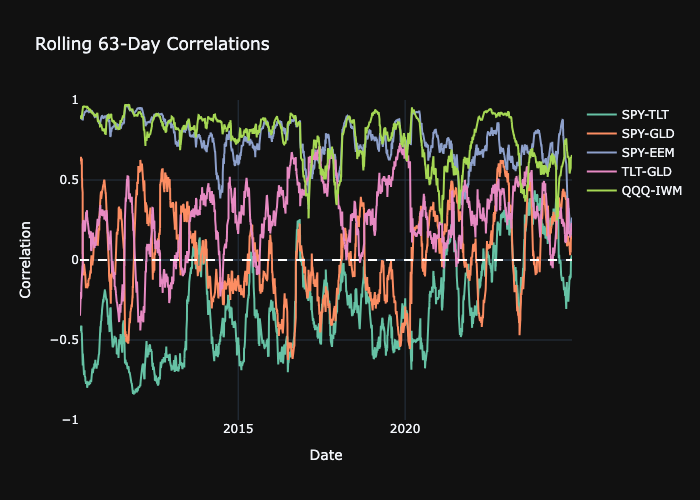

In [10]:
# Plot rolling correlations
fig = go.Figure()

colors = px.colors.qualitative.Set2

for i, col in enumerate(rolling_corr_df.columns):
    fig.add_trace(go.Scatter(
        x=rolling_corr_df.index,
        y=rolling_corr_df[col],
        mode='lines',
        name=col,
        line=dict(color=colors[i % len(colors)])
    ))

fig.add_hline(y=0, line_dash="dash", line_color="white")

fig.update_layout(
    title=f'Rolling {window}-Day Correlations',
    xaxis_title='Date',
    yaxis_title='Correlation',
    yaxis=dict(range=[-1, 1]),
    template='plotly_dark',
    height=500
)
fig.show()

## 5. Correlation Breakdown During Stress

In [11]:
# Identify stress periods (bottom 10% of SPY returns)
if 'SPY' in returns_df.columns:
    spy_returns = returns_df['SPY']
    stress_threshold = spy_returns.quantile(0.10)
    normal_threshold = spy_returns.quantile(0.90)
    
    stress_days = returns_df[spy_returns <= stress_threshold]
    normal_days = returns_df[(spy_returns > stress_threshold) & (spy_returns < normal_threshold)]
    
    # Calculate correlations in different regimes
    stress_corr = stress_days.corr()
    normal_corr = normal_days.corr()
    corr_diff = stress_corr - normal_corr
    
    print(f"Stress days: {len(stress_days)} ({len(stress_days)/len(returns_df)*100:.1f}%)")
    print(f"Normal days: {len(normal_days)} ({len(normal_days)/len(returns_df)*100:.1f}%)")

Stress days: 378 (10.0%)
Normal days: 3017 (80.0%)


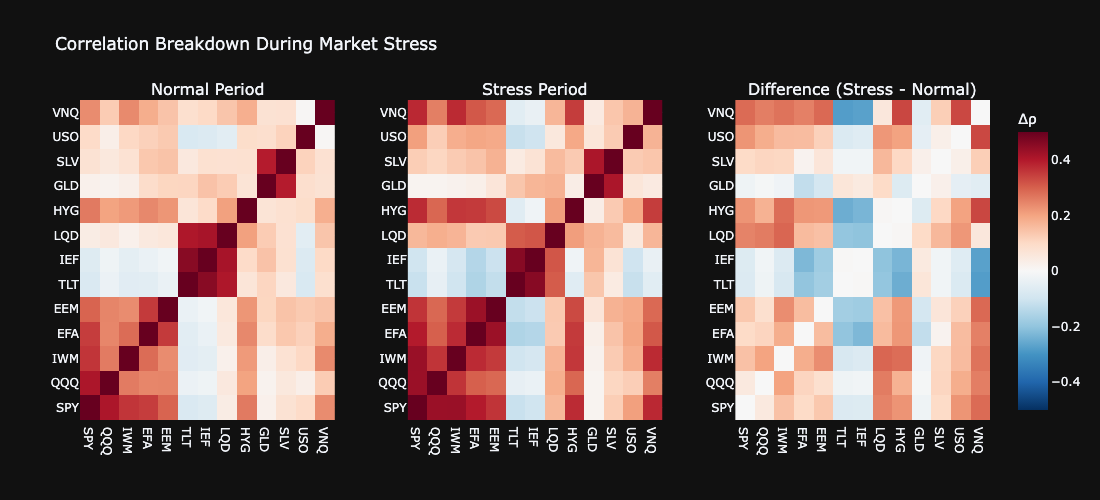

In [12]:
# Compare correlations: Normal vs Stress
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=['Normal Period', 'Stress Period', 'Difference (Stress - Normal)'],
    horizontal_spacing=0.08
)

# Normal
fig.add_trace(
    go.Heatmap(
        z=normal_corr.values,
        x=normal_corr.columns,
        y=normal_corr.index,
        colorscale='RdBu_r',
        zmin=-1, zmax=1,
        showscale=False
    ),
    row=1, col=1
)

# Stress
fig.add_trace(
    go.Heatmap(
        z=stress_corr.values,
        x=stress_corr.columns,
        y=stress_corr.index,
        colorscale='RdBu_r',
        zmin=-1, zmax=1,
        showscale=False
    ),
    row=1, col=2
)

# Difference
fig.add_trace(
    go.Heatmap(
        z=corr_diff.values,
        x=corr_diff.columns,
        y=corr_diff.index,
        colorscale='RdBu_r',
        zmin=-0.5, zmax=0.5,
        colorbar=dict(title='Δρ')
    ),
    row=1, col=3
)

fig.update_layout(
    title='Correlation Breakdown During Market Stress',
    template='plotly_dark',
    height=500,
    width=1100
)
fig.show()

In [13]:
# Average correlation increase during stress
avg_normal = normal_corr.values[np.triu_indices_from(normal_corr.values, k=1)].mean()
avg_stress = stress_corr.values[np.triu_indices_from(stress_corr.values, k=1)].mean()

print(f"\nAverage Correlation:")
print(f"  Normal periods: {avg_normal:.3f}")
print(f"  Stress periods: {avg_stress:.3f}")
print(f"  Increase:       {avg_stress - avg_normal:.3f} (+{(avg_stress/avg_normal - 1)*100:.1f}%)")


Average Correlation:
  Normal periods: 0.247
  Stress periods: 0.310
  Increase:       0.062 (+25.2%)


## 6. Diversification Metrics

In [14]:
def calculate_diversification_ratio(weights, cov_matrix):
    """
    Diversification Ratio = weighted avg vol / portfolio vol
    DR > 1 means diversification is adding value
    """
    vols = np.sqrt(np.diag(cov_matrix))
    weighted_avg_vol = np.dot(weights, vols)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return weighted_avg_vol / port_vol

def calculate_effective_n(weights, cov_matrix):
    """
    Effective number of bets based on marginal contribution to risk
    """
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    mrc = np.dot(cov_matrix, weights) / port_vol
    ctb = weights * mrc  # Contribution to risk
    ctb_pct = ctb / ctb.sum()
    ctb_pct = np.maximum(ctb_pct, 1e-10)  # Avoid log(0)
    return np.exp(-np.sum(ctb_pct * np.log(ctb_pct)))  # Entropy-based N

# Calculate for equal weight portfolio
cov_matrix = returns_df.cov() * 252  # Annualized
n_assets = len(returns_df.columns)
equal_weights = np.ones(n_assets) / n_assets

dr = calculate_diversification_ratio(equal_weights, cov_matrix.values)
eff_n = calculate_effective_n(equal_weights, cov_matrix.values)

print(f"\nEqual-Weight Portfolio Diversification:")
print(f"  Diversification Ratio: {dr:.2f}x")
print(f"  Effective N (bets):    {eff_n:.1f} / {n_assets}")
print(f"  Concentration:         {n_assets/eff_n:.1f}x vs ideal")


Equal-Weight Portfolio Diversification:
  Diversification Ratio: 1.60x
  Effective N (bets):    10.2 / 13
  Concentration:         1.3x vs ideal


## 7. Principal Component Analysis

In [15]:
# Standardize returns
standardized = (returns_df - returns_df.mean()) / returns_df.std()

# PCA via eigendecomposition
corr_matrix = standardized.corr()
eigenvalues, eigenvectors = np.linalg.eigh(corr_matrix)

# Sort by eigenvalue (descending)
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Variance explained
var_explained = eigenvalues / eigenvalues.sum()
cum_var = np.cumsum(var_explained)

print("Principal Component Analysis:")
print(f"{'PC':<5} {'Eigenvalue':<12} {'Var %':<10} {'Cum %':<10}")
print("-" * 37)
for i in range(min(6, len(eigenvalues))):
    print(f"PC{i+1:<3} {eigenvalues[i]:>10.2f} {var_explained[i]*100:>8.1f}% {cum_var[i]*100:>8.1f}%")

Principal Component Analysis:
PC    Eigenvalue   Var %      Cum %     
-------------------------------------
PC1         6.04     46.4%     46.4%
PC2         2.84     21.9%     68.3%
PC3         1.51     11.6%     79.9%
PC4         0.77      5.9%     85.8%
PC5         0.41      3.2%     89.0%
PC6         0.35      2.7%     91.7%


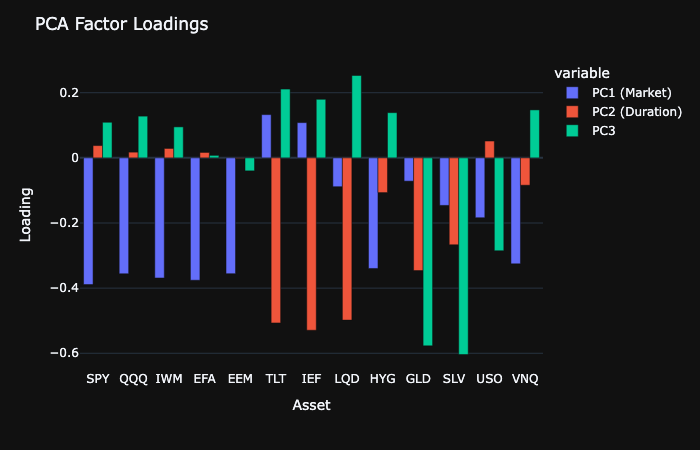

In [16]:
# PCA loadings for first 3 components
loadings = pd.DataFrame(
    eigenvectors[:, :3],
    index=returns_df.columns,
    columns=['PC1 (Market)', 'PC2 (Duration)', 'PC3']
)

fig = px.bar(
    loadings.reset_index(),
    x='index',
    y=['PC1 (Market)', 'PC2 (Duration)', 'PC3'],
    barmode='group',
    labels={'index': 'Asset', 'value': 'Loading'}
)

fig.update_layout(
    title='PCA Factor Loadings',
    template='plotly_dark',
    height=450
)
fig.show()

In [ ]:
# Scree plot
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['Scree Plot', 'Cumulative Variance']
)

# Eigenvalues
fig.add_trace(
    go.Bar(
        x=[f'PC{i+1}' for i in range(len(eigenvalues))],
        y=eigenvalues,
        marker_color='cyan'
    ),
    row=1, col=1
)

# Cumulative variance
fig.add_trace(
    go.Scatter(
        x=[f'PC{i+1}' for i in range(len(eigenvalues))],
        y=cum_var * 100,
        mode='lines+markers',
        line=dict(color='lime')
    ),
    row=1, col=2
)
fig.add_hline(y=80, line_dash="dash", line_color="yellow", row=1, col=2)

fig.update_layout(
    title='PCA Variance Analysis',
    template='plotly_dark',
    showlegend=False,
    height=400
)
fig.show()

## 8. Time-Varying Correlation (DCC-GARCH Lite)

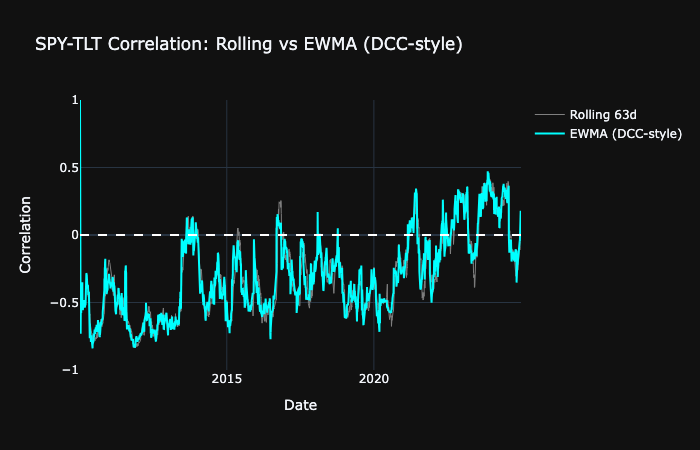

In [17]:
# Simplified DCC-style rolling correlation with exponential weighting
def ewm_correlation(x, y, halflife=20):
    """EWMA correlation (simplified DCC)"""
    alpha = 1 - np.exp(-np.log(2) / halflife)
    
    # Demean
    x = x - x.mean()
    y = y - y.mean()
    
    # EWMA variances and covariance
    var_x = x.pow(2).ewm(alpha=alpha).mean()
    var_y = y.pow(2).ewm(alpha=alpha).mean()
    cov_xy = (x * y).ewm(alpha=alpha).mean()
    
    return cov_xy / np.sqrt(var_x * var_y)

# Calculate DCC-style correlations
if 'SPY' in returns_df.columns and 'TLT' in returns_df.columns:
    dcc_corr = ewm_correlation(returns_df['SPY'], returns_df['TLT'], halflife=20)
    
    fig = go.Figure()
    
    # Simple rolling for comparison
    simple_rolling = returns_df['SPY'].rolling(63).corr(returns_df['TLT'])
    
    fig.add_trace(go.Scatter(
        x=simple_rolling.index,
        y=simple_rolling,
        mode='lines',
        name='Rolling 63d',
        line=dict(color='gray', width=1)
    ))
    
    fig.add_trace(go.Scatter(
        x=dcc_corr.index,
        y=dcc_corr,
        mode='lines',
        name='EWMA (DCC-style)',
        line=dict(color='cyan', width=2)
    ))
    
    fig.add_hline(y=0, line_dash="dash", line_color="white")
    
    fig.update_layout(
        title='SPY-TLT Correlation: Rolling vs EWMA (DCC-style)',
        xaxis_title='Date',
        yaxis_title='Correlation',
        yaxis=dict(range=[-1, 1]),
        template='plotly_dark',
        height=450
    )
    fig.show()

## 9. Correlation Network Visualization

In [18]:
# Create network coordinates using spring layout (simplified)
def simple_spring_layout(corr_matrix, iterations=50):
    """Simple force-directed layout"""
    n = len(corr_matrix)
    np.random.seed(42)
    pos = np.random.rand(n, 2) - 0.5
    
    for _ in range(iterations):
        for i in range(n):
            force = np.zeros(2)
            for j in range(n):
                if i != j:
                    diff = pos[j] - pos[i]
                    dist = np.linalg.norm(diff) + 0.01
                    # Attraction proportional to correlation
                    attraction = corr_matrix.iloc[i, j] * 0.1
                    # Repulsion inversely proportional to distance
                    repulsion = -0.01 / (dist ** 2)
                    force += diff / dist * (attraction + repulsion)
            pos[i] += force * 0.1
    
    return pos

positions = simple_spring_layout(full_corr)

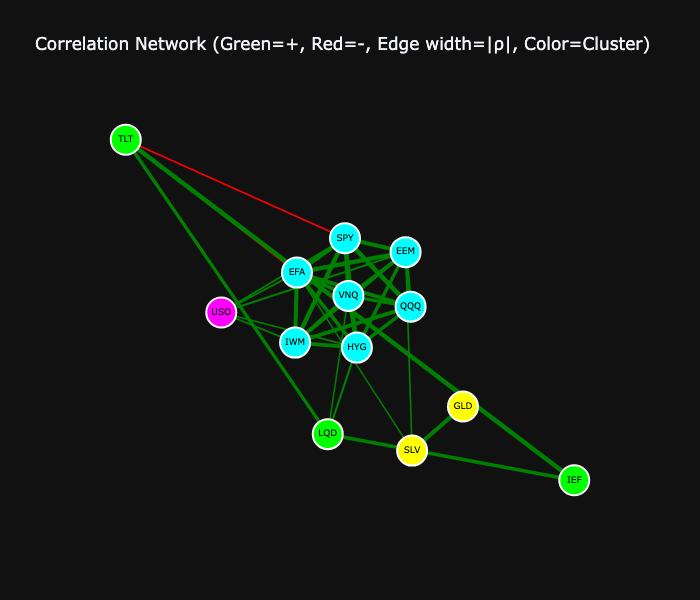

In [19]:
# Create network plot
fig = go.Figure()

# Add edges (correlations)
for i in range(len(full_corr)):
    for j in range(i+1, len(full_corr)):
        corr_val = full_corr.iloc[i, j]
        if abs(corr_val) > 0.3:  # Only show significant correlations
            color = 'green' if corr_val > 0 else 'red'
            width = abs(corr_val) * 5
            
            fig.add_trace(go.Scatter(
                x=[positions[i, 0], positions[j, 0]],
                y=[positions[i, 1], positions[j, 1]],
                mode='lines',
                line=dict(color=color, width=width),
                showlegend=False,
                hoverinfo='skip'
            ))

# Add nodes
cluster_colors = {1: 'cyan', 2: 'magenta', 3: 'yellow', 4: 'lime'}
node_colors = [cluster_colors.get(c, 'white') for c in clusters]

fig.add_trace(go.Scatter(
    x=positions[:, 0],
    y=positions[:, 1],
    mode='markers+text',
    marker=dict(size=30, color=node_colors, line=dict(width=2, color='white')),
    text=full_corr.columns,
    textposition='middle center',
    textfont=dict(size=9, color='black'),
    hoverinfo='text',
    hovertext=[f"{col}<br>Cluster: {c}" for col, c in zip(full_corr.columns, clusters)]
))

fig.update_layout(
    title='Correlation Network (Green=+, Red=-, Edge width=|ρ|, Color=Cluster)',
    template='plotly_dark',
    showlegend=False,
    height=600,
    xaxis=dict(visible=False),
    yaxis=dict(visible=False)
)
fig.show()

## 10. Summary Report

In [20]:
print("="*70)
print("CROSS-ASSET CORRELATION & DIVERSIFICATION ANALYSIS")
print("="*70)

print(f"\n1. UNIVERSE STATISTICS")
print(f"   Assets: {len(returns_df.columns)}")
print(f"   Period: {returns_df.index.min().date()} to {returns_df.index.max().date()}")
print(f"   Observations: {len(returns_df):,} days")

print(f"\n2. AVERAGE CORRELATIONS")
upper_tri = full_corr.values[np.triu_indices_from(full_corr.values, k=1)]
print(f"   Mean correlation: {upper_tri.mean():.3f}")
print(f"   Median correlation: {np.median(upper_tri):.3f}")
print(f"   Range: [{upper_tri.min():.2f}, {upper_tri.max():.2f}]")

print(f"\n3. CLUSTER ANALYSIS")
for c in sorted(set(clusters)):
    members = [full_corr.columns[i] for i in range(len(clusters)) if clusters[i] == c]
    print(f"   Cluster {c}: {', '.join(members)}")

print(f"\n4. STRESS CORRELATION BEHAVIOR")
print(f"   Normal period avg ρ: {avg_normal:.3f}")
print(f"   Stress period avg ρ: {avg_stress:.3f}")
print(f"   Correlation spike: +{(avg_stress - avg_normal)*100:.1f}%")

print(f"\n5. DIVERSIFICATION METRICS (Equal Weight)")
print(f"   Diversification Ratio: {dr:.2f}x")
print(f"   Effective N:           {eff_n:.1f} / {n_assets}")

print(f"\n6. PCA FACTOR DECOMPOSITION")
print(f"   PC1 (Market) explains: {var_explained[0]*100:.1f}%")
print(f"   PC1+PC2 explains:      {cum_var[1]*100:.1f}%")
print(f"   PCs for 80% variance:  {np.argmax(cum_var >= 0.8) + 1}")

print(f"\n7. KEY INSIGHTS")
print(f"   - Correlations rise {(avg_stress/avg_normal - 1)*100:.0f}% during stress")
print(f"   - Market factor (PC1) dominates ({var_explained[0]*100:.0f}% var)")
print(f"   - Effective diversification is {eff_n:.0f} assets, not {n_assets}")
print(f"   - Bonds provide negative correlation to equities")

print("\n" + "="*70)

CROSS-ASSET CORRELATION & DIVERSIFICATION ANALYSIS

1. UNIVERSE STATISTICS
   Assets: 13
   Period: 2010-01-05 to 2024-12-31
   Observations: 3,773 days

2. AVERAGE CORRELATIONS
   Mean correlation: 0.301
   Median correlation: 0.245
   Range: [-0.32, 0.93]

3. CLUSTER ANALYSIS
   Cluster 1: SPY, QQQ, IWM, EFA, EEM, HYG, VNQ
   Cluster 2: USO
   Cluster 3: GLD, SLV
   Cluster 4: TLT, IEF, LQD

4. STRESS CORRELATION BEHAVIOR
   Normal period avg ρ: 0.247
   Stress period avg ρ: 0.310
   Correlation spike: +6.2%

5. DIVERSIFICATION METRICS (Equal Weight)
   Diversification Ratio: 1.60x
   Effective N:           10.2 / 13

6. PCA FACTOR DECOMPOSITION
   PC1 (Market) explains: 46.4%
   PC1+PC2 explains:      68.3%
   PCs for 80% variance:  4

7. KEY INSIGHTS
   - Correlations rise 25% during stress
   - Market factor (PC1) dominates (46% var)
   - Effective diversification is 10 assets, not 13
   - Bonds provide negative correlation to equities



## Summary

This CQF-level example covered:

1. **Multi-Asset Universe**: 13 ETFs across asset classes
2. **Correlation Analysis**: Full-sample and rolling
3. **Hierarchical Clustering**: Asset groupings
4. **Stress Testing**: Correlation breakdown analysis
5. **Diversification Metrics**: DR, Effective N
6. **PCA Factor Extraction**: Market & duration factors
7. **Time-Varying Correlation**: EWMA (DCC-style)
8. **Network Visualization**: Correlation structure

**Applications**:
- Portfolio construction & optimization
- Risk management & hedging
- Factor model development
- Stress testing & scenario analysis